# TrueCar Price Prediction: Linear Regression, MLE, AIC/BIC, and Final Model

This notebook treats used-car price as a regression problem. We start with an interpretable
linear model, connect ordinary least squares to maximum likelihood estimation, compare
models using AIC/BIC, inspect diagnostics, and then fit a stronger predictive pipeline.


## Hypotheses

Let `sales_price` be the observed listing price.

**Overall regression hypothesis**

- $H_0$: Mileage, age, make, fuel type, and metro area do not improve prediction beyond an intercept-only model.
- $H_A$: At least one predictor has a non-zero association with price.

**Mileage hypothesis**

- $H_0: \beta_{mileage}=0$
- $H_A: \beta_{mileage}<0$

We expect higher mileage to be associated with lower price, holding other features constant.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

DATA_DIR = Path("../data")
CLEAN_DATA = DATA_DIR / "truecar_clean_combined.csv"
MODEL_DATA = DATA_DIR / "truecar_model_ready.csv"


In [2]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


## Import Modeling Data


In [3]:
if MODEL_DATA.exists():
    cars = pd.read_csv(MODEL_DATA)
else:
    cars = pd.read_csv(CLEAN_DATA)

cars = cars.dropna(subset=["sales_price", "odometer_miles", "vehicle_age", "make", "model"]).copy()
cars = cars[cars["sales_price"] > 0].copy()
cars["log_sales_price"] = np.log(cars["sales_price"])
cars["log_odometer"] = np.log1p(cars["odometer_miles"])

print(cars.shape)
cars.head()


(8629, 18)


,sales_price,price_tier,year,vehicle_age,make,model,trim,odometer_miles,fuel_type,exterior,interior,dealer_state,dealer_distance_miles,source_metro,feature_count,standard_feature_count,log_sales_price,log_odometer
0,18000.0,below_market,2018,8,Acura,ILX,with Premium Package,60784,Gas,Crystal Black Pearl,Ebony,MA,26.0,boston_ma,0,0,9.798127,11.015098
1,25499.0,near_market,2022,4,Acura,ILX,Sedan w/Premium/A-SPEC Package,26314,Gas,Platinum White Pearl,Red,MA,12.0,boston_ma,0,0,10.146395,10.177894
2,35399.0,near_market,2025,1,Acura,Integra,A-Spec Technology Package CVT,4617,Gas,Platinum White Pearl,Ebony,CA,2688.0,san-francisco_ca,0,0,10.474439,8.437717
3,34680.0,near_market,2025,1,Acura,Integra,A-Spec Technology Package CVT,2551,Gas,Platinum White Pearl,Ebony,CA,2678.0,san-francisco_ca,0,0,10.453918,7.844633
4,28883.0,near_market,2023,3,Acura,Integra,CVT w/A-Spec Technology Package,41138,Gas,Platinum White Pearl,Red,TX,1691.0,austin_tx,0,0,10.271008,10.624712


## Train-Test Split


In [4]:
train, test = train_test_split(cars, test_size=0.25, random_state=571)
print(train.shape, test.shape)


(6471, 18) (2158, 18)


## Interpretable OLS Models


In [5]:
simple_model = smf.ols("log_sales_price ~ log_odometer + vehicle_age", data=train).fit()

medium_model = smf.ols(
    "log_sales_price ~ log_odometer + vehicle_age + feature_count + C(fuel_type) + C(source_metro)",
    data=train,
).fit()

top_makes = train["make"].value_counts().head(12).index
train_ols = train.assign(make_lumped=np.where(train["make"].isin(top_makes), train["make"], "Other"))
test_ols = test.assign(make_lumped=np.where(test["make"].isin(top_makes), test["make"], "Other"))

full_model = smf.ols(
    "log_sales_price ~ log_odometer + vehicle_age + feature_count + standard_feature_count + "
    "C(fuel_type) + C(source_metro) + C(make_lumped)",
    data=train_ols,
).fit()

comparison = pd.DataFrame({
    "model": ["simple", "medium", "full"],
    "adj_r2": [simple_model.rsquared_adj, medium_model.rsquared_adj, full_model.rsquared_adj],
    "log_likelihood": [simple_model.llf, medium_model.llf, full_model.llf],
    "AIC": [simple_model.aic, medium_model.aic, full_model.aic],
    "BIC": [simple_model.bic, medium_model.bic, full_model.bic],
})
comparison


,model,adj_r2,log_likelihood,AIC,BIC
0,simple,0.531639,-3273.414823,6552.829646,6573.154904
1,medium,0.554252,-3093.220586,6216.441172,6318.002415
2,full,0.624131,-2537.894240,5129.788480,5312.598718


## MLE Connection

OLS can be viewed as maximum likelihood estimation when residuals are assumed to be
independent and normally distributed:

$$
y_i = x_i^T\beta + \epsilon_i, \quad \epsilon_i \sim N(0, \sigma^2)
$$

Maximizing this likelihood is equivalent to minimizing the residual sum of squares. AIC and
BIC use the maximized log-likelihood but penalize model complexity.


In [6]:
resid = full_model.resid
n = full_model.nobs
rss = np.sum(resid ** 2)
sigma2_mle = rss / n
manual_loglik = -0.5 * n * (np.log(2 * np.pi) + np.log(sigma2_mle) + 1)

pd.DataFrame({
    "quantity": ["statsmodels logLik", "manual Gaussian logLik", "sigma2 MLE", "RSS"],
    "value": [full_model.llf, manual_loglik, sigma2_mle, rss],
})


,quantity,value
0,statsmodels logLik,-2537.894240
1,manual Gaussian logLik,-2537.894240
2,sigma2 MLE,0.128725
3,RSS,829.374174


## Coefficient Table and Hypothesis Tests


In [7]:
coef_table = full_model.summary2().tables[1]
coef_table.loc[coef_table.index.str.contains("log_odometer|vehicle_age|feature_count", regex=True)]


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
log_odometer,-0.116352,0.004947,-23.520384,2.085353e-117,-0.126050,-0.106655
vehicle_age,-0.079657,0.001253,-63.580715,0.000000e+00,-0.082113,-0.077201
feature_count,0.000000,0.000000,NaN,NaN,0.000000,0.000000
standard_feature_count,0.000000,0.000000,NaN,NaN,0.000000,0.000000


In [8]:
mileage_coef = full_model.params["log_odometer"]
mileage_p_two_sided = full_model.pvalues["log_odometer"]
mileage_p_one_sided_negative = mileage_p_two_sided / 2 if mileage_coef < 0 else 1 - mileage_p_two_sided / 2

print(f"log_odometer coefficient: {mileage_coef:.4f}")
print(f"one-sided p-value for beta_mileage < 0: {mileage_p_one_sided_negative:.4g}")


log_odometer coefficient: -0.1164
one-sided p-value for beta_mileage < 0: 1.043e-117


## Regression Diagnostics


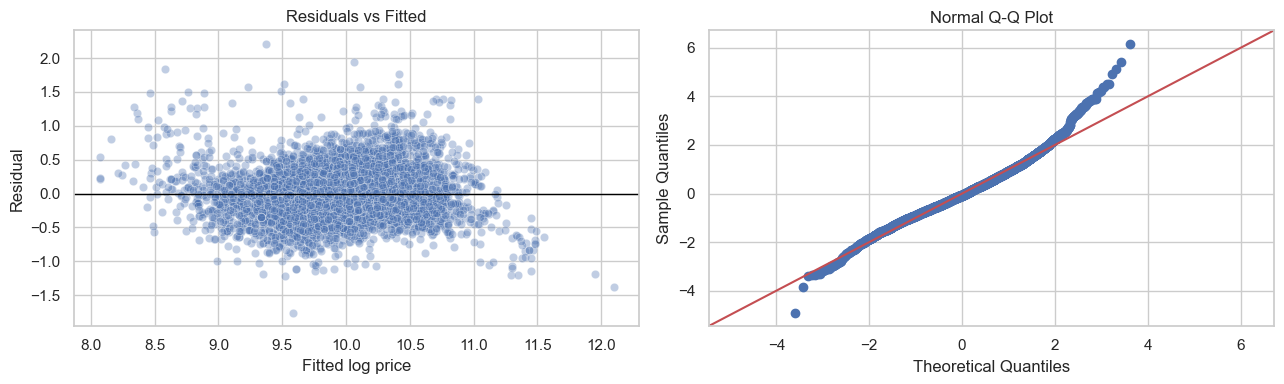

In [9]:
fitted = full_model.fittedvalues
residuals = full_model.resid

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.scatterplot(x=fitted, y=residuals, alpha=0.35, ax=axes[0])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Residuals vs Fitted")
axes[0].set_xlabel("Fitted log price")
axes[0].set_ylabel("Residual")

sm.qqplot(residuals, line="45", fit=True, ax=axes[1])
axes[1].set_title("Normal Q-Q Plot")
plt.tight_layout()


In [10]:
influence = full_model.get_influence()
cooks = influence.cooks_distance[0]
used_index = full_model.model.data.row_labels
influence_source = train_ols.loc[used_index]
influential = pd.DataFrame({
    "cooks_distance": cooks,
    "sales_price": influence_source["sales_price"].values,
    "make": influence_source["make"].values,
    "model": influence_source["model"].values,
    "odometer_miles": influence_source["odometer_miles"].values,
}).sort_values("cooks_distance", ascending=False)

influential.head(10)


,cooks_distance,sales_price,make,model,odometer_miles
4247,1.984143,6888.0,Ford,F-150,94636
2624,0.012466,44883.0,Mercedes-Benz,Sprinter,5
5337,0.007739,47338.0,Mercedes-Benz,Sprinter,20
3789,0.007145,29820.0,Toyota,Prius,5
1395,0.005597,23995.0,Ford,Escape,10
4135,0.005459,33500.0,Porsche,911,33404
6035,0.005459,106990.0,Lamborghini,Gallardo,9036
6156,0.005286,20991.0,Volkswagen,Phaeton,90289
5875,0.005196,25311.0,Volkswagen,Taos,6
1984,0.005186,23628.0,Hyundai,Elantra,8


## Test-Set Evaluation for OLS


In [11]:
def regression_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        "model": label,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse,
        "R2": r2_score(y_true, y_pred),
    }

pred_log = full_model.predict(test_ols)
pred_price = np.exp(pred_log)

ols_eval = test_ols[["sales_price"]].assign(pred_price=pred_price).dropna()
ols_metrics = regression_metrics(ols_eval["sales_price"], ols_eval["pred_price"], "OLS log-price")
pd.DataFrame([ols_metrics])


,model,MAE,RMSE,R2
0,OLS log-price,7077.227383,13766.791932,0.359244


## Predictive Pipelines


In [12]:
numeric_features = ["vehicle_age", "odometer_miles", "dealer_distance_miles", "feature_count", "standard_feature_count"]
categorical_features = ["make", "model", "fuel_type", "exterior", "interior", "dealer_state", "source_metro"]
numeric_features = [c for c in numeric_features if c in cars.columns]
categorical_features = [c for c in categorical_features if c in cars.columns]

X = cars[numeric_features + categorical_features]
y = cars["sales_price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=571)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20))]), categorical_features),
    ],
    remainder="drop",
    sparse_threshold=0.0,
)

models = {
    "Ridge": Ridge(alpha=10),
    "Random Forest": RandomForestRegressor(n_estimators=250, min_samples_leaf=5, random_state=571, n_jobs=1),
    "Histogram Gradient Boosting": HistGradientBoostingRegressor(max_iter=250, learning_rate=0.06, random_state=571),
}

rows = []
fitted_models = {}
for name, estimator in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", estimator)])
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
    pred = pipe.predict(X_test)
    rows.append(regression_metrics(y_test, pred, name))

results = pd.DataFrame(rows).sort_values("RMSE")
results


,model,MAE,RMSE,R2
2,Histogram Gradient Boosting,4708.598851,10757.438795,0.608913
1,Random Forest,5553.135449,11510.258102,0.552260
0,Ridge,5902.910197,11705.856196,0.536914


## Cross-Validation


In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=571)
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

cv_rows = []
for name, estimator in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", estimator)])
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=1)
    cv_rows.append({
        "model": name,
        "CV_MAE": -scores["test_MAE"].mean(),
        "CV_RMSE": -scores["test_RMSE"].mean(),
        "CV_R2": scores["test_R2"].mean(),
    })

pd.DataFrame(cv_rows).sort_values("CV_RMSE")


## Predicted vs Actual Plot


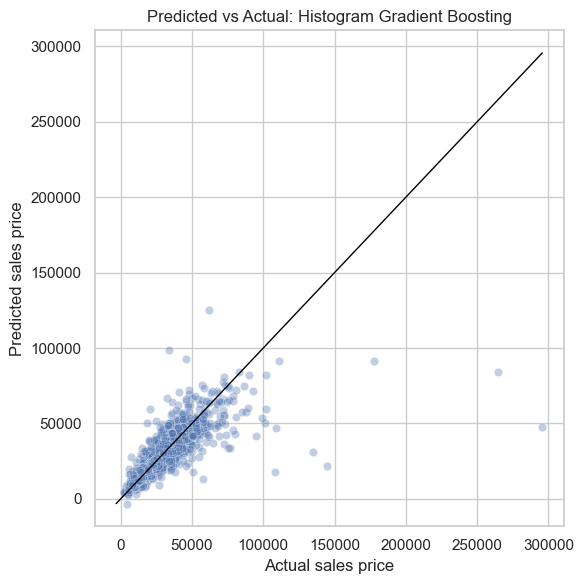

In [ ]:
best_name = results.iloc[0]["model"]
best_model = fitted_models[best_name]
best_pred = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x=y_test, y=best_pred, alpha=0.35, ax=ax)
low = min(y_test.min(), best_pred.min())
high = max(y_test.max(), best_pred.max())
ax.plot([low, high], [low, high], color="black", linewidth=1)
ax.set_title(f"Predicted vs Actual: {best_name}")
ax.set_xlabel("Actual sales price")
ax.set_ylabel("Predicted sales price")
plt.tight_layout()


## Conclusion

The OLS model is valuable for interpretation, hypothesis testing, and AIC/BIC comparison.
The machine-learning pipelines are more flexible and are usually better suited for final
prediction. A careful report should include both: an interpretable statistical model and
a predictive model evaluated on held-out data.
